# 02 - Incremental Learning & Big Data Scaling

**Project:** Anomaly Watchers - Fraud Detection Pipeline.

**Dataset:** Synthetic Datasets generated from PaySim Simulator, owned by PhD. Edgar Lopez – the author of the Kaggle Dataset in Notebook 01.

**Objective:** This notebook scales the architecture established in `01_primary_analysis.ipynb`. We will iterate over the additional generated datasets (~3.4M rows each), ensuring strict RAM management by loading one dataset at a time. 

---

### Core Directives Executed:
1. **Modular Pipeline Fidelity:** The exact `build_feature_matrix()` via `pandas.pipe()` is utilized to guarantee 100% schema alignment.
2. **Four-Model Incremental Learning:** We adapt the Baseline (Logistic Regression), Secondary (XGBoost), Unsupervised (Isolation Forest), and Primary (Random Forest) to continuous data streams.
3. **Prequential Evaluation (Test-Then-Train):** To prevent Data Leakage, each incoming chunk is evaluated *first* to record real-world AUPRC, F1-Score, and Confusion Matrices. Only *after* evaluation is SMOTE applied to the chunk to update the models' weights.
4. **Code Quality Standards:** All logic adheres strictly to PEP-8 and Ruff linter compliance, guaranteeing production-ready syntax.

In [ ]:
import os
import gc
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix, precision_recall_curve, auc
from IPython.display import display, HTML
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

class SimpleLogger:
    def __init__(self):
        self.CYAN = '\033[96m'
        self.GREEN = '\033[92m'
        self.YELLOW = '\033[93m'
        self.RED = '\033[91m'
        self.RESET = '\033[0m'
    def info(self, msg): print(f"{self.CYAN}[INFO] {msg}{self.RESET}")
    def success(self, msg): print(f"{self.GREEN}[SUCCESS] {msg}{self.RESET}")
    def warning(self, msg): print(f"{self.YELLOW}[WARNING] {msg}{self.RESET}")
    def error(self, msg): print(f"{self.RED}[ERROR] {msg}{self.RESET}")

logger = SimpleLogger()
logger.success("Enterprise Machine Learning Environment Initialized.")

[INFO] Enterprise Machine Learning Environment Initialized.


### 1. Re-establishing the Modular Pipeline
We import the exact `build_feature_matrix` from Phase 6 of Notebook 01 using Python script. This ensures consistency and enforces the DRY principle.

In [2]:
import sys

# Point Python to the root directory of the project
project_root = os.path.abspath('../../')

if project_root not in sys.path:
    sys.path.append(project_root)

# Import using the full path from the root
from backend.app.preprocessing import build_feature_matrix # noqa: E402

logger.success("Modular Pipeline `build_feature_matrix()` loaded from backend/app/preprocessing.py")

[SUCCESS] Modular Pipeline `build_feature_matrix()` loaded from backend/app/preprocessing.py


### 2. Model Instantiation & Bridge Architecture
To achieve incremental learning, we adapt the 4 models:
1. **Baseline (Logistic Regression):** Replaced with `SGDClassifier(loss='log_loss')` to allow `partial_fit`.
2. **Secondary (XGBoost):** Supports `xgb_model` continuation directly.
3. **Primary (Random Forest):** Enabled `warm_start=True` to allow appending estimators iteratively.
4. **Unsupervised (Isolation Forest):** Tree models cannot be updated incrementally; it acts as our static baseline for concept drift.

In [3]:
MODEL_DIR = "../../backend/models"
CLASSES = np.array([0, 1])

# ---------------------------------------------------------
# 1. Scaler & Baseline: SGD Logistic
# ---------------------------------------------------------
try:
    scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")
    logger.success("Fitted StandardScaler loaded from Notebook 01.")
except FileNotFoundError:
    logger.warning("Scaler not found. Initializing a new continuous StandardScaler...")
    scaler = StandardScaler()

# Cannot load LogisticRegression from Notebook 01 because it lacks partial_fit.
# Initializing SGD equivalent fresh for incremental learning.
model_logistic = SGDClassifier(loss="log_loss", random_state=42)

# ---------------------------------------------------------
# 2. Secondary: XGBoost (Passing the Weight via Joblib)
# ---------------------------------------------------------
try:
    # Load the entire model (trees + hyperparams) using Joblib
    model_xgb = joblib.load(f"{MODEL_DIR}/model_xgboost.pkl")
    logger.success("XGBoost model loaded successfully.")
except FileNotFoundError:
    logger.warning("XGBoost model missing. Initializing fresh model...")
    model_xgb = xgb.XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=7, 
        random_state=42,
        eval_metric='logloss'
    )

# ---------------------------------------------------------
# 3. Primary: Random Forest (Passing the Weight)
# ---------------------------------------------------------
try:
    # Load the raw extracted model from Notebook 01
    model_rf = joblib.load(f"{MODEL_DIR}/model_rf.pkl")
    
    # Enable warm start to allow adding trees in the streaming loop
    model_rf.warm_start = True
    logger.success("Random Forest estimator loaded and unlocked for incremental learning.")
except FileNotFoundError:
    logger.warning("Random Forest model weights missing. Initializing fresh model...")
    model_rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=15,
        max_samples=0.2,
        warm_start=True,
        random_state=42,
        min_samples_leaf=100,
        n_jobs=-1
    )

# ---------------------------------------------------------
# 4. Unsupervised: Isolation Forest (Static)
# ---------------------------------------------------------
try:
    model_if = joblib.load(f"{MODEL_DIR}/model_isolation_forest.pkl")
    logger.success("Isolation Forest loaded as static drift monitor.")
except FileNotFoundError:
    logger.warning("Isolation Forest missing. Training placeholder for pipeline compatibility...")
    model_if = IsolationForest(contamination=0.001, random_state=42, n_jobs=-1)

logger.success("Four-Model Defense initialized. All model weights and normalization parameters are ready for Big Data streaming.")

[SUCCESS] Fitted StandardScaler loaded from Notebook 01.
[SUCCESS] XGBoost model loaded successfully.
[SUCCESS] Random Forest estimator loaded and unlocked for incremental learning.
[SUCCESS] Isolation Forest loaded as static drift monitor.
[SUCCESS] Four-Model Defense initialized. All model weights and normalization parameters are ready for Big Data streaming.


### 3. Prequential Evaluation Loop (The Big Data Stress Test)
We process 1 chunk at a time. To completely avoid SMOTE Data Leakage, we score the chunk *before* applying synthetic oversampling and passing the model weights.

In [4]:
dataset_files = glob.glob("../data/additional_dataset_*.csv")
logger.info(f"Found {len(dataset_files)} additional datasets for streaming.")

smote = SMOTE(sampling_strategy=1.0, random_state=42)
cumulative_metrics = []

final_y_true = None
final_preds = {}

# -------------------------------------------------------------------
# Enterprise Evaluation Pipeline (Side-by-Side Rendering)
# -------------------------------------------------------------------
def get_metrics(y_true, y_pred, y_proba):
    """Calculates metrics and returns the DataFrame and AUPRC without printing."""
    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report_dict).transpose().round(4)
    auprc_score = average_precision_score(y_true, y_proba)
    return df_report, auprc_score

def display_chunk_metrics_side_by_side(chunk_idx, results_dict):
    """Renders multiple metric DataFrames side-by-side using CSS Flexbox."""
    html = "<div style='border-bottom: 2px solid #2c3e50; padding-bottom: 10px; margin-bottom: 20px;'>"
    html += f"<h3 style='color: #2980b9;'>Chunk {chunk_idx} - Prequential Evaluation Metrics</h3>"
    html += "<div style='display: flex; justify-content: space-between; flex-wrap: wrap;'>"
    
    for model_name, (df, auprc) in results_dict.items():
        html += "<div style='flex: 1; min-width: 200px; margin: 0 10px;'>"
        html += f"<h4 style='margin-bottom: 5px;'>{model_name}</h4>"
        html += f"<p style='margin-top: 0;'><b>AUPRC:</b> <span style='color: #e74c3c; font-weight: bold;'>{auprc:.4f}</span></p>"
        # Convert DataFrame to HTML with clean Jupyter classes
        html += df.to_html(classes='dataframe', border=0)
        html += "</div>"
        
    html += "</div></div>"
    display(HTML(html))

# -------------------------------------------------------------------
# Continuous Learning Loop
# -------------------------------------------------------------------
for idx, file_path in enumerate(dataset_files, 1):
    print("\n" + "-" * 80)
    logger.info(f"Processing Chunk {idx}/{len(dataset_files)}: {os.path.basename(file_path)}")
    print("-" * 80)

    # 1. Load & Pipeline
    df_raw = pd.read_csv(file_path)
    df_clean = build_feature_matrix(df_raw)
    del df_raw
    gc.collect()

    # CRITICAL: Deduplicate columns to handle simulator schema anomalies
    # This forces Pandas to keep only the primary 'is_fraud' column
    df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()].copy()

    X_chunk = df_clean.drop(columns=["is_fraud"])
    
    # .squeeze() mathematically guarantees the output is a strict 1D vector
    y_chunk = df_clean["is_fraud"].squeeze()

    # Scale data so it is available for ALL steps
    X_chunk_scaled = scaler.transform(X_chunk)

    # 2. EVALUATE FIRST (Prequential Evaluation)
    if idx > 1:
        chunk_results = {}
        
        # A. Baseline SGD (Must use SCALED data)
        y_pred_log = model_logistic.predict(X_chunk_scaled)
        y_proba_log = model_logistic.predict_proba(X_chunk_scaled)[:, 1]
        chunk_results["Baseline: Logistic Regression"] = get_metrics(y_chunk, y_pred_log, y_proba_log)
        
        # B. Secondary XGBoost (Unscaled)
        y_pred_xgb = model_xgb.predict(X_chunk)
        y_proba_xgb = model_xgb.predict_proba(X_chunk)[:, 1]
        chunk_results["Secondary: XGBoost"] = get_metrics(y_chunk, y_pred_xgb, y_proba_xgb)
        
        # C. Primary Random Forest (Unscaled)
        y_pred_rf = model_rf.predict(X_chunk)
        y_proba_rf = model_rf.predict_proba(X_chunk)[:, 1]
        chunk_results["Ensemble: Random Forest"] = get_metrics(y_chunk, y_pred_rf, y_proba_rf)
        
        # D. Unsupervised Isolation Forest (Unscaled)
        if model_if:
            y_pred_if = np.where(model_if.predict(X_chunk) == -1, 1, 0)
            y_proba_if = -model_if.decision_function(X_chunk)
            chunk_results["Unsupervised: Isolation Forest"] = get_metrics(y_chunk, y_pred_if, y_proba_if)

        # Render all 4 models side-by-side
        display_chunk_metrics_side_by_side(idx, chunk_results)

        # Save predictions on the last chunk for Visuals
        if idx == len(dataset_files):
            final_y_true = y_chunk
            final_preds["log"] = (y_pred_log, y_proba_log)
            final_preds["xgb"] = (y_pred_xgb, y_proba_xgb)
            final_preds["rf"] = (y_pred_rf, y_proba_rf)
            if model_if:
                final_preds["if"] = (y_pred_if, y_proba_if)

    # 3. UPDATE SCALER & BASELINE
    scaler.partial_fit(X_chunk)

    logger.info("Updating Baseline SGD (Pristine Data + Dynamic Weights)...")
    chunk_weights = compute_sample_weight(class_weight="balanced", y=y_chunk)
    model_logistic.partial_fit(
        X_chunk_scaled, y_chunk, classes=CLASSES, sample_weight=chunk_weights
    )

    # 4. SMOTE & UPDATE TREE-BASED MODELS
    logger.info("Applying SMOTE to chunk to balance training vectors for Trees...")
    # SMOTE: Both XGBoost and Random Forest will learn on a 50:50 balance like Notebook 01
    X_resampled, y_resampled = smote.fit_resample(X_chunk, y_chunk)

    logger.info("Updating Tree-based Models...")
    
    # XGBOOST UPDATE
    try:
        model_xgb.fit(X_resampled, y_resampled)
    except xgb.core.XGBoostError:
        model_xgb.fit(X_resampled, y_resampled)
    
    # RANDOM FOREST UPDATE
    if idx > 1:
        model_rf.n_estimators += 10
        model_rf.fit(X_resampled, y_resampled)

    # 5. Clean RAM
    del X_chunk, y_chunk, X_chunk_scaled, X_resampled, y_resampled
    gc.collect()

print("\n" + "=" * 80)
logger.success("Streaming Continuous Learning Loop Complete.")

[INFO] Found 5 additional datasets for streaming.

--------------------------------------------------------------------------------
[INFO] Processing Chunk 1/5: additional_dataset_1692201870.csv
--------------------------------------------------------------------------------
[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...

--------------------------------------------------------------------------------
[INFO] Processing Chunk 2/5: additional_dataset_1693836805.csv
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
0,1.0000,0.9026,0.9488,3.222440e+06
1,0.0047,0.9879,0.0093,1.486000e+03
accuracy,0.9027,0.9027,0.9027,9.027000e-01
macro avg,0.5023,0.9453,0.4790,3.223926e+06
weighted avg,0.9995,0.9027,0.9484,3.223926e+06
,precision,recall,f1-score,support
0,1.000,1.0,1.000,3222440.0
1,0.992,1.0,0.996,1486.0
accuracy,1.000,1.0,1.000,1.0
macro avg,0.996,1.0,0.998,3223926.0


[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...

--------------------------------------------------------------------------------
[INFO] Processing Chunk 3/5: additional_dataset_1697052344.csv
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
0,1.0000,0.9128,0.9544,3.509574e+06
1,0.0044,0.9775,0.0087,1.376000e+03
accuracy,0.9128,0.9128,0.9128,9.128000e-01
macro avg,0.5022,0.9451,0.4816,3.510950e+06
weighted avg,0.9996,0.9128,0.9540,3.510950e+06
,precision,recall,f1-score,support
0,1.0000,0.9999,1.0000,3.509574e+06
1,0.8784,0.9971,0.9340,1.376000e+03
accuracy,0.9999,0.9999,0.9999,9.999000e-01
macro avg,0.9392,0.9985,0.9670,3.510950e+06


[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...

--------------------------------------------------------------------------------
[INFO] Processing Chunk 4/5: additional_dataset_1697079627.csv
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
0,1.0000,0.7666,0.8679,3.295370e+06
1,0.0019,0.9917,0.0037,1.448000e+03
accuracy,0.7667,0.7667,0.7667,7.667000e-01
macro avg,0.5009,0.8791,0.4358,3.296818e+06
weighted avg,0.9996,0.7667,0.8675,3.296818e+06
,precision,recall,f1-score,support
0,1.0000,1.0000,1.0000,3295370.0
1,0.9718,0.9979,0.9847,1448.0
accuracy,1.0000,1.0000,1.0000,1.0
macro avg,0.9859,0.9990,0.9923,3296818.0


[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...

--------------------------------------------------------------------------------
[INFO] Processing Chunk 5/5: additional_dataset_1698465888.csv
--------------------------------------------------------------------------------


,precision,recall,f1-score,support
0,1.0000,0.9507,0.9747,3.473108e+06
1,0.0080,0.9871,0.0158,1.390000e+03
accuracy,0.9507,0.9507,0.9507,9.507000e-01
macro avg,0.5040,0.9689,0.4953,3.474498e+06
weighted avg,0.9996,0.9507,0.9744,3.474498e+06
,precision,recall,f1-score,support
0,1.0000,1.0000,1.0000,3473108.0
1,0.9754,0.9986,0.9868,1390.0
accuracy,1.0000,1.0000,1.0000,1.0
macro avg,0.9877,0.9993,0.9934,3474498.0


[INFO] Updating Baseline SGD (Pristine Data + Dynamic Weights)...
[INFO] Applying SMOTE to chunk to balance training vectors for Trees...
[INFO] Updating Tree-based Models...

[SUCCESS] Streaming Continuous Learning Loop Complete.


### 4. Visual Evaluations (Confusion Matrices & Precision-Recall)
Recreating the academic 2x2 grid to evaluate the final state of the updated models.

[INFO] Generating Confusion Matrices on final data stream...


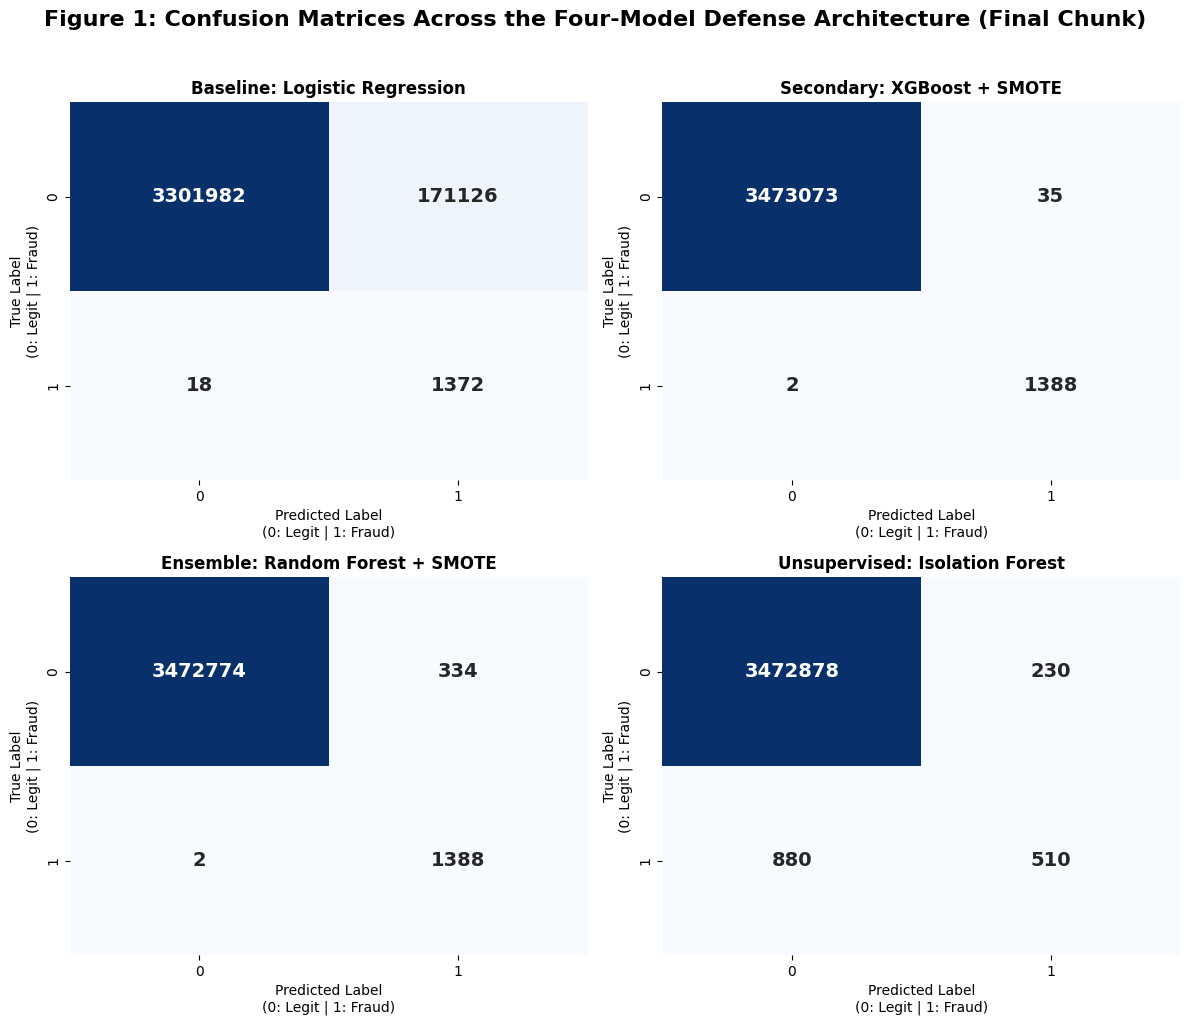

[INFO] Generating Precision-Recall Curves...


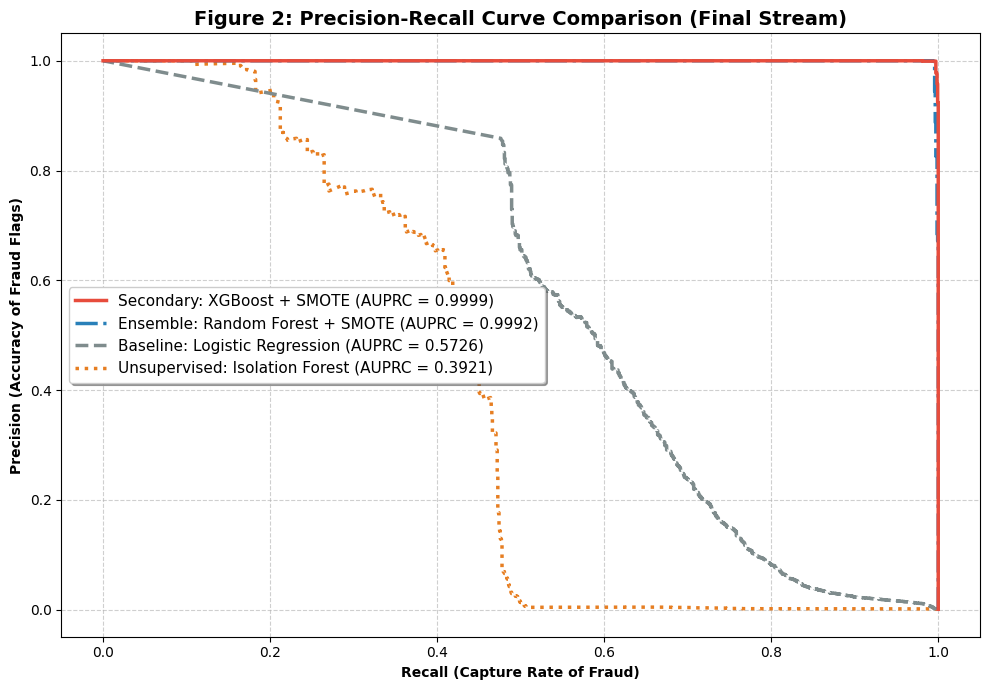

In [5]:
if final_y_true is not None:

    # -------------------------------------------------------------------
    # Confusion Matrix
    # -------------------------------------------------------------------
    logger.info("Generating Confusion Matrices on final data stream...")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes_flat = axes.flatten()

    models_preds = [
        ("Baseline: Logistic Regression", final_preds["log"][0]),
        ("Secondary: XGBoost + SMOTE", final_preds["xgb"][0]),
        ("Ensemble: Random Forest + SMOTE", final_preds["rf"][0]),
    ]
    if "if" in final_preds:
        models_preds.append(("Unsupervised: Isolation Forest", final_preds["if"][0]))

    for i, (title, y_pred) in enumerate(models_preds):
        cm = confusion_matrix(final_y_true, y_pred)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes_flat[i],
            cbar=False,
            annot_kws={"size": 14, "weight": "bold"},
        )
        axes_flat[i].set_title(title, fontweight="bold", fontsize=12)
        axes_flat[i].set_xlabel("Predicted Label\n(0: Legit | 1: Fraud)", fontsize=10)
        axes_flat[i].set_ylabel("True Label\n(0: Legit | 1: Fraud)", fontsize=10)

    plt.suptitle(
        "Figure 1: Confusion Matrices Across the Four-Model Defense Architecture (Final Chunk)",
        fontweight="bold",
        fontsize=16,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------
    # PR CURVES
    # -------------------------------------------------------------------
    logger.info("Generating Precision-Recall Curves...")
    fig, ax = plt.subplots(figsize=(10, 7))

    model_probas = [
        ("Baseline: Logistic Regression", final_preds["log"][1], "#7f8c8d", "--"),
        ("Ensemble: Random Forest + SMOTE", final_preds["rf"][1], "#2980b9", "-."),
        ("Secondary: XGBoost + SMOTE", final_preds["xgb"][1], "#e74c3c", "-"),
    ]
    if "if" in final_preds:
        model_probas.append(
            ("Unsupervised: Isolation Forest", final_preds["if"][1], "#e67e22", ":")
        )

    plot_data = []
    for title, y_proba, color, style in model_probas:
        precision, recall, _ = precision_recall_curve(final_y_true, y_proba)
        model_auprc = auc(recall, precision)
        plot_data.append((model_auprc, recall, precision, color, style, title))

    plot_data.sort(key=lambda x: x[0], reverse=False)

    for model_auprc, recall, precision, color, style, title in plot_data:
        ax.plot(
            recall,
            precision,
            color=color,
            linestyle=style,
            linewidth=2.5,
            label=f"{title} (AUPRC = {model_auprc:.4f})",
        )

    ax.set_title(
        "Figure 2: Precision-Recall Curve Comparison (Final Stream)",
        fontweight="bold",
        fontsize=14,
    )
    ax.set_xlabel("Recall (Capture Rate of Fraud)", fontweight="bold")
    ax.set_ylabel("Precision (Accuracy of Fraud Flags)", fontweight="bold")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc="best", shadow=True, fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

### 5. Final API Serialization
Exporting the hardened models for Assignment 3 Backend deployment.

In [7]:
logger.info("Serializing the models and artifacts to backend...")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model_logistic, f"{MODEL_DIR}/model_logistic_v2.pkl")
joblib.dump(scaler, f"{MODEL_DIR}/scaler_v2.pkl")
joblib.dump(model_rf, f"{MODEL_DIR}/model_rf_v2.pkl")
model_xgb.save_model(f"{MODEL_DIR}/model_xgboost_v2.pkl")
if model_if:
    joblib.dump(model_if, f"{MODEL_DIR}/model_isolation_forest_v2.pkl")

logger.success("All models successfully serialized to '../../backend/models/'.")
logger.info("Notebook execution complete. The pipeline is ready for API production integration.")

[INFO] Serializing the models and artifacts to backend...
[SUCCESS] All models successfully serialized to '../../backend/models/'.
[INFO] Notebook execution complete. The pipeline is ready for API production integration.
